In [1]:
import urllib
import numpy as np
import os
import netCDF4 as nc
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import drms

import sys
folder_path = '/Users/coletamburri/Desktop/DKIST_Code/Flare_Patrol_Analysis/gbm_data_tools-1.1.1/' 

# Or use a relative path if the folder is in a fixed location relative to the notebook
# Example: a 'src' folder one level up from the current notebook's directory
# folder_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))

# Add the folder to the system path
if folder_path not in sys.path:
    sys.path.append(folder_path)
    
import gbm
from gbm.plot import Spectrum

from gbm import test_data_dir
# import the CTIME and CSPEC data classes
from gbm.data import Ctime, Cspec
from gbm.binning.binned import rebin_by_time

/Users/coletamburri/Desktop/DKIST_Code/Flare_Patrol_Analysis/gbm_data_tools-1.1.1/gbm/plot/lal_post_subs.py:184: UserWarning: Basemap not installed. Some functionality not available.
  warnings.warn('Basemap not installed. Some functionality not available.')


In [2]:
def datenum_to_datetime(datenum):
    """
    Convert Matlab datenum into Python datetime.
    :param datenum: Date in datenum format
    :return:        Datetime object corresponding to datenum.
    """
    days = datenum % 1
    hours = days % 1 * 24
    minutes = hours % 1 * 60
    seconds = minutes % 1 * 60
    return datetime.fromordinal(int(datenum)) \
           + timedelta(days=int(days)) \
           + timedelta(hours=int(hours)) \
           + timedelta(minutes=int(minutes)) \
           + timedelta(seconds=round(seconds)) \
           - timedelta(days=366)



In [5]:
# ViSP - H-beta
filehb = '/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/Hblc.npz'
hbdat = np.load(filehb)

# ViSP - H-eps
filehe = '/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/heps_lc.npz'
#filehe = '/Users/coletamburri/Desktop/heps_lc.npz'

hedat = np.load(filehe)

# ViSP - Ca II
filecaii = '/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/CaIIHlc.npz'
#filecaii = '/Users/coletamburri/Desktop/CaIIHlc.npz'
caiidat = np.load(filecaii)

In [6]:
times_hb = hbdat['times']
lc_hb = hbdat['flare']

times_heps = hedat['times']
lc_heps = hedat['flare']

times_caii = caiidat['times']
lc_caii = caiidat['flare']



In [7]:
np.shape(lc_hb)

(1273, 2548)

In [8]:

lc_hb2 = []
times_hb2 = list(times_hb)
for i in range(14):
    scanmean = np.mean(lc_hb[(91*i):(91*(i+1)),:])#-0.12 #arbitrary scale factor to make pretty
    lc_hb2.append((scanmean*1.6)+1e7)
    #times_hb2.append(times_hb[startind+(91*i)+40])

lc_heps2 = []
times_heps2 = list(times_heps)
for i in range(14):
    scanmean = np.mean(lc_heps[(91*i):(91*(i+1)),:])
    lc_heps2.append(scanmean*2)
    #times_heps2.append(times_heps[(91*i)+40])

lc_caii2 = []
times_caii2 = list(times_caii)
for i in range(14):
    scanmean = np.mean(lc_caii[(91*i):(91*(i+1)),:])#+0.01
    lc_caii2.append(scanmean)
    #times_caii2.append(times_caii[startind+(91*i)+40])

In [9]:
np.nanmax(lc_heps2)

np.float64(27862026.074969843)

In [10]:
np.nanmax(lc_hb2)-np.nanmax(lc_heps2)

np.float64(16218155.80136466)

In [11]:
t_visp = np.arange(datetime(2024,8,11,22,31,57),
              datetime(2024,8,11,22,36,31), 
              timedelta(seconds=21)).astype(datetime)
len(t_visp)

14

In [12]:
#download aia data
results = Fido.search(a.Time("2024/8/11 22:00:00", "2024/8/11 23:00:00"),
                     a.Instrument.aia,a.Wavelength(304*u.angstrom))

client = drms.Client()
keys = [
    "T_REC",
    "T_OBS",
    "DATAMIN",
    "DATAMAX",
    "DATAMEAN",
    "DATARMS",
    "DATAMEDN",
    "DATASKEW",
    "DATAKURT",
    "DATA",
    "QUALITY",
]

print("Querying series info...")
series_info = client.info("aia.lev1_euv_12s")
series_info_lev1 = client.info("aia.lev1")


Querying series info...


DrmsQueryError: Command '/home/jsoc/releases/jsoc-v10.0.5/bin/linux_x86_64/show_series -qz JSOC_DBHOST=hmidb2:5432 JSOC_DBNAME=jsoc JSOC_DBUSER=apache' returned non-zero status code 1 [status=5]

In [13]:
qstr = "aia.lev1_euv_12s[2024-08-11T22:00:01Z/1h@12s][304]"

# Get keyword values for the selected timespan and wavelength
print(f"Querying keyword data...\n -> {qstr}")
result = client.query(qstr, key=keys)
print(f" -> {len(result)} lines retrieved.")

# Only use entries with QUALITY==0
result = result[result.QUALITY == 0]
print(f" -> {len(result)} lines after QUALITY selection.")

# Convert T_REC strings to datetime and use it as index for the series
result.index = drms.to_datetime(result.T_REC)

Querying keyword data...
 -> aia.lev1_euv_12s[2024-08-11T22:00:01Z/1h@12s][304]


DrmsQueryError: Command '/home/jsoc/releases/jsoc-v10.0.5/bin/linux_x86_64/show_series -qz JSOC_DBHOST=hmidb2:5432 JSOC_DBNAME=jsoc JSOC_DBUSER=apache' returned non-zero status code 1 [status=5]

In [14]:
# sci_xrsf-l2-avg1m_g17_d20220819_v2-2-0.nc	
# new_x = "/Users/coletamburri/Desktop/19_December_2022.nc"
# #x = 'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l2/data/xrsf-l2-flx1s_science/2024/08/sci_xrsf-l2-flx1s_g16_d20240827_v2-2-0.nc	'
# x = 'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l2/data/xrsf-l2-flx1s_science/2022/12/sci_xrsf-l2-flx1s_g16_d20221228_v2-2-0.nc'
# urllib.request.urlretrieve(x, new_x)
fn = "/Users/coletamburri/Desktop/Misc_DKIST/DKIST_Data_Tools_misc/GOES_NETCDF_Flare_Files/11_August_2024.nc"
ds = nc.Dataset(fn)

In [15]:
t=ds['time']
ds['xrsa1_flux']

t = np.arange(datetime(2024,8,11,0,0,0),
              datetime(2024,8,12,0,0,0), 
              timedelta(seconds=1)).astype(datetime)

t2 = np.arange(datetime(2024,8,11,22,0,0),
              datetime(2024,8,11,23,0,0), 
              timedelta(seconds=12)).astype(datetime)

In [16]:
loadvbilc = np.load('/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/vbi_lc_extended.npz',allow_pickle='True')
#timesvbi=loadvbilc['times']
lcvbi=loadvbilc['lc']
# t3 = np.arange(datetime(2024,8,11,22,31,26),
#               datetime(2024,8,11,22,38,57), 
#               timedelta(seconds=2.666)).astype(datetime)

#for extended
t3 = np.arange(datetime(2024,8,11,22,25,39),
              datetime(2024,8,11,22,38,57), 
              timedelta(seconds=2.666)).astype(datetime)

In [17]:
specdata = '/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/11Aug_Fermi/glg_cspec_n5_240811_v00.pha'

In [18]:
cspec = Cspec.open(specdata)
t4 = np.arange(datetime(2024,8,11,0,0,0),
              datetime(2024,8,11,23,59,59), 
              timedelta(seconds=4.096)).astype(datetime)

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/347469137.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(energy_sliced0.rates))
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/347469137.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(energy_sliced1.rates))
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/347469137.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(energy_sliced2.rates))


(2.0, 4.5)

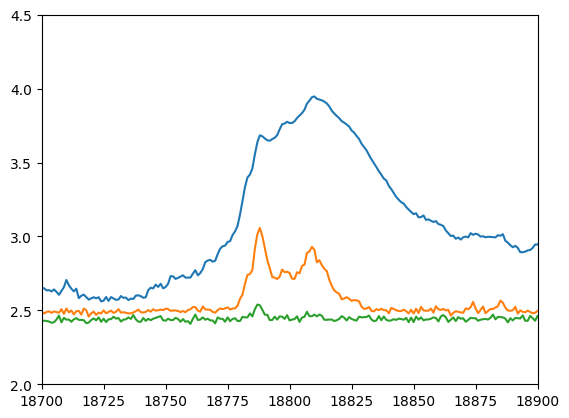

In [19]:
energy_sliced0 = cspec.slice_energy((4,15)).to_lightcurve()

energy_sliced1 = cspec.slice_energy((15,25)).to_lightcurve()

energy_sliced2 = cspec.slice_energy((25,50)).to_lightcurve()
plt.plot(np.log10(energy_sliced0.rates))
plt.plot(np.log10(energy_sliced1.rates))
plt.plot(np.log10(energy_sliced2.rates))
plt.xlim([18700,18900])
plt.ylim([2,4.5])
#plt.xlim([datetime(2024, 8, 11, 21, 0, 11, 424000),datetime(2024, 8, 11, 23, 40, 11, 424000)])

In [20]:


# 1. Define the specific starting date
start_date = datetime(2001, 1, 1, 0, 0, 0) # Year, Month, Day, Hour, Minute, Second

# 2. Define the duration in seconds as a timedelta object
t4=[]
for i in range(len(cspec.data.time_centroids)):

    elapsed_seconds = cspec.data.time_centroids[i]
    time_delta = timedelta(seconds=elapsed_seconds)
    
    # 3. Add the timedelta to the start date to get the resulting datetime
    result_datetime = start_date + time_delta
    t4.append(result_datetime)

In [21]:
# fried
fried = np.load('/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/11aug2024_fried.npz')

friedvbi=fried['fried']
# t3 = np.arange(datetime(2024,8,11,22,31,26),
#               datetime(2024,8,11,22,38,57), 
#               timedelta(seconds=2.666)).astype(datetime)

#for extended
t11 = np.arange(datetime(2024,8,11,22,23,34),
              datetime(2024,8,11,23,16,14), 
              timedelta(seconds=2.666)).astype(datetime)

In [22]:
grey = np.arange(np.min(friedvbi)-2,np.max(friedvbi)+10,.01)
grey1 = [grey,grey]

In [23]:
print(np.max(friedvbi))
print(np.min(friedvbi))

11.46541101242995
0.0


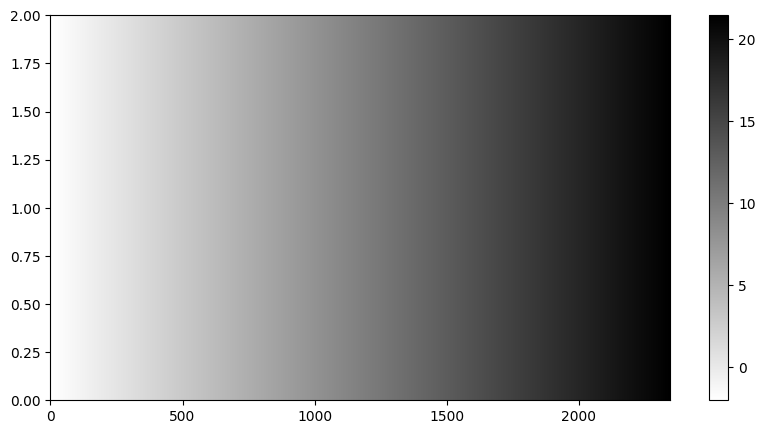

In [24]:
fig,ax=plt.subplots(figsize=(10,5))
im = ax.pcolormesh(grey1,cmap='grey_r')
cbar = fig.colorbar(im)


In [25]:
Xf,Yf = np.meshgrid(t11,np.arange(10))

In [26]:
len(t11)

1186

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/3866922012.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  lns1 = ax.plot(t,np.array(ds['xrsb1_flux']),linewidth=3,color='k',label=r'XRS 1-8$\AA$')
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/3866922012.py:5: RuntimeWarning: divide by zero encountered in log10
  lns4 = ax4.plot(t4,np.log10(energy_sliced0.rates),c='#77AADD',label='GBM 4-15 keV',linewidth=3,linestyle='solid')
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/3866922012.py:6: RuntimeWarning: divide by zero encountered in log10
  lns5 = ax4.plot(t4,np.log10(energy_sliced1.rates),c='#DDCC77',label='GBM 15-25 keV',linewidth=3,linestyle='solid')
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_30186/3866922012.py:7: RuntimeWarning: divide by zero encountered in log10
  lns6 = ax4.plot(t4,np

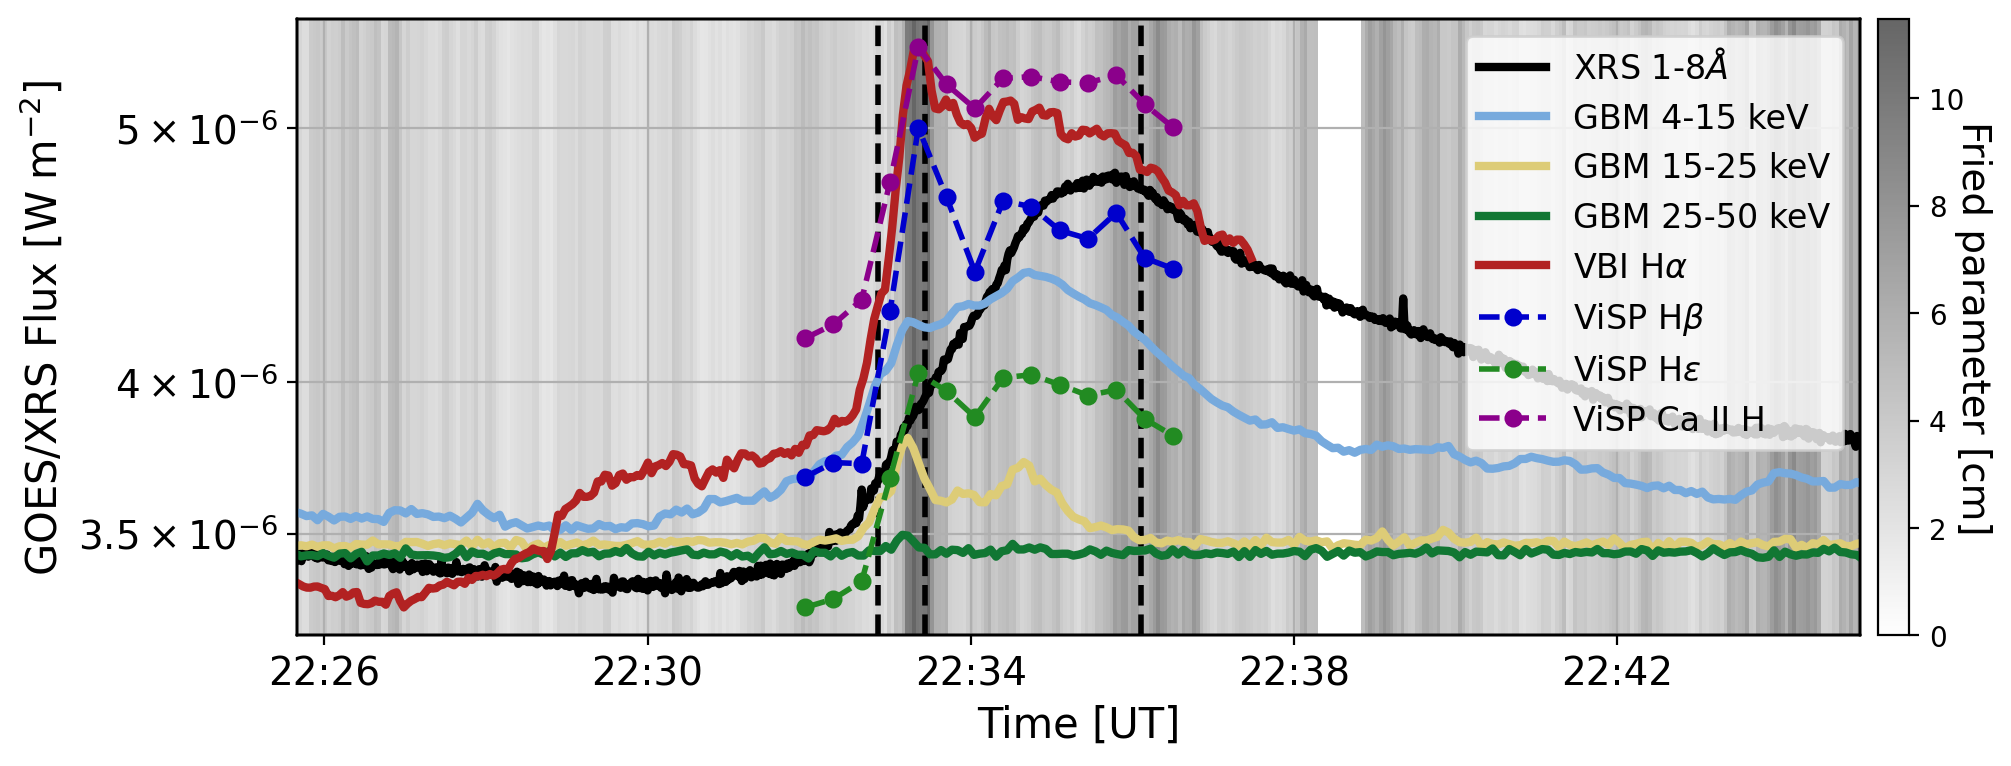

In [32]:
fig,ax = plt.subplots(figsize=(12,4),dpi=200)
lns1 = ax.plot(t,np.array(ds['xrsb1_flux']),linewidth=3,color='k',label=r'XRS 1-8$\AA$')
ax2=ax.twinx()
ax4=ax.twinx()
lns4 = ax4.plot(t4,np.log10(energy_sliced0.rates),c='#77AADD',label='GBM 4-15 keV',linewidth=3,linestyle='solid')
lns5 = ax4.plot(t4,np.log10(energy_sliced1.rates),c='#DDCC77',label='GBM 15-25 keV',linewidth=3,linestyle='solid')
lns6 = ax4.plot(t4,np.log10(energy_sliced2.rates),c='#117733',label='GBM 25-50 keV',linewidth=3,linestyle='solid')
ax3=ax.twinx()
lns3=ax3.plot(t3[:267],lcvbi[:267],c='firebrick',label=r'VBI H$\alpha$',linewidth=3)
ax5=ax.twinx()
lns7 = ax5.plot(t_visp,lc_hb2,c='mediumblue',label=r'ViSP H$\beta$',linewidth=2,linestyle='dashed',marker='.',markersize=11)
lns8 = ax5.plot(t_visp,lc_heps2,c='forestgreen',label=r'ViSP H$\epsilon$',linewidth=2,linestyle='dashed',marker='.',markersize=11)

lns9 = ax5.plot(t_visp,lc_caii2,c='darkmagenta',label=r'ViSP Ca II H',linewidth=2,linestyle='dashed',marker='.',markersize=11)

fried_norm_arr = []

for i in range(10):
    fried_norm_arr.append(friedvbi)

data = fried_norm_arr

# 2. Define a continuous transition from fully transparent black to opaque black
# Format: (R, G, B, A)
colors = [(.4, .4, .4, 0.0), (.4, .4, .4, 1.0)]
cmap = mcolors.LinearSegmentedColormap.from_list("black_alpha", colors)
ax10=ax3.twinx()
ax10.set_zorder(ax.get_zorder() - 1)
ax.set_facecolor('none')
ax2.set_facecolor('none')
ax3.set_facecolor('none')

ax4.set_facecolor('none')
ax5.set_facecolor('none')

# 3. Plot the data
im = ax10.pcolormesh(Xf,Yf,data, cmap=cmap)
ax10.set_yticks([])
# 4. Create the continuous colorbar
cbar = plt.colorbar(im,pad=0.01)
cbar.set_label('Fried parameter [cm]', rotation=270, labelpad=10,fontsize=14)

# 5. Crucial: Add a solid background (e.g., white) behind the colorbar 
# This prevents the colorbar from blending with the interface or notebook theme
cbar.ax.set_facecolor('white') 



ax4.set_ylim([2,5.3])

lns = lns1+lns4+lns5+lns6+lns3+lns7+lns8+lns9


labs = [l.get_label() for l in lns]
ax2.legend(lns, labs,loc="upper right",fontsize=12)
ax.set_ylabel(r'GOES/XRS Flux [$\text{W}\;\text{m}^{-2}$]',fontsize=15)
ax3.set_yticks([])
ax4.set_yticks([])
ax5.set_yticks([])
#ax6.set_yticks([])
#ax7.set_yticks([])
ax.set_yscale("log")


ax.set_xlabel('Time [UT]',fontsize=15)
ax.set_xlim([datetime(2024,8,11,22,25,40),datetime(2024,8,11,22,45,00)])
ax.set_ylim([3.2e-6,5.5e-6])

ax.set_xticks([datetime(2024,8,11,22,26,0),datetime(2024,8,11,22,30,0),datetime(2024,8,11,22,34,00),datetime(2024,8,11,22,38,00),datetime(2024,8,11,22,42,00)],['22:26','22:30','22:34','22:38','22:42'])
ax2.set_yticks([])
ax.grid()
ax.set_yticks([3.5e-6,4e-6,5e-6])

ax.axvline(datetime(2024,8,11,22,32,51),color='k',linestyle='--',linewidth=2)
ax.axvline(datetime(2024,8,11,22,33,26),color='k',linestyle='--',linewidth=2)
ax.axvline(datetime(2024,8,11,22,36,6),color='k',linestyle='--',linewidth=2)


ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

#ax.axvline(datetime(2024,8,11,22,33,12))

#ax.axvline(datetime(2024,8,11,22,35,45))



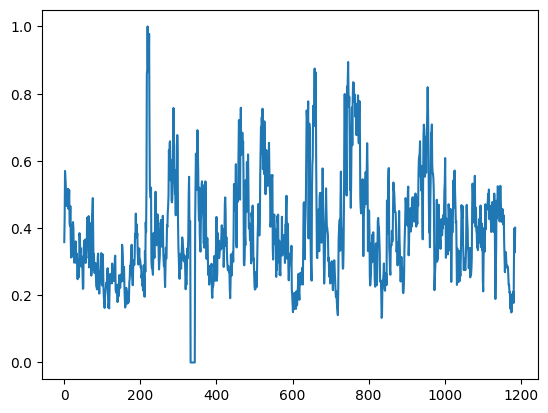

In [28]:
plt.plot(friedvbi/np.nanmax(friedvbi))

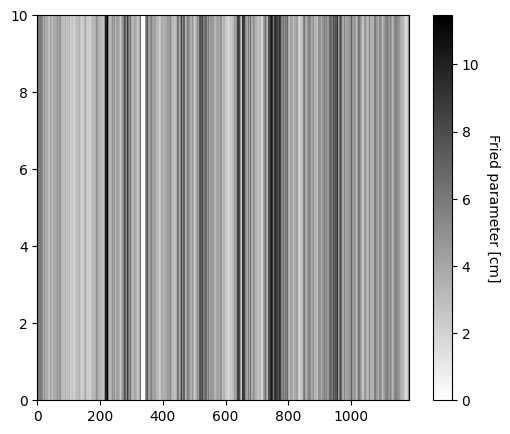

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Generate sample data (values from 0 to 4)
data = fried_norm_arr

# 2. Define a continuous transition from fully transparent black to opaque black
# Format: (R, G, B, A)
colors = [(0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 1.0)]
cmap = mcolors.LinearSegmentedColormap.from_list("black_alpha", colors)

# 3. Plot the data
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(data, cmap=cmap)

# 4. Create the continuous colorbar
cbar = plt.colorbar(im)
cbar.set_label('Fried parameter [cm]', rotation=270, labelpad=15)

# 5. Crucial: Add a solid background (e.g., white) behind the colorbar 
# This prevents the colorbar from blending with the interface or notebook theme
cbar.ax.set_facecolor('white') 

plt.show()

In [75]:
np.nanmax(fried_norm)

np.float64(0.5738408334419174)

In [137]:
t_visp,

(array([datetime.datetime(2024, 8, 11, 22, 31, 57),
        datetime.datetime(2024, 8, 11, 22, 32, 18),
        datetime.datetime(2024, 8, 11, 22, 32, 39),
        datetime.datetime(2024, 8, 11, 22, 33),
        datetime.datetime(2024, 8, 11, 22, 33, 21),
        datetime.datetime(2024, 8, 11, 22, 33, 42),
        datetime.datetime(2024, 8, 11, 22, 34, 3),
        datetime.datetime(2024, 8, 11, 22, 34, 24),
        datetime.datetime(2024, 8, 11, 22, 34, 45),
        datetime.datetime(2024, 8, 11, 22, 35, 6),
        datetime.datetime(2024, 8, 11, 22, 35, 27),
        datetime.datetime(2024, 8, 11, 22, 35, 48),
        datetime.datetime(2024, 8, 11, 22, 36, 9),
        datetime.datetime(2024, 8, 11, 22, 36, 30)], dtype=object),)